In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')



In [5]:
df=pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\Projects\Loan Deafult\Loan_Default.csv")


In [4]:
print("shape:", df.shape)
print("\ncolumns:" , df.columns.tolist())
print("\nFirst 5 rows")
df.head()

shape: (148670, 34)

columns: ['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'property_value', 'construction_type', 'occupancy_type', 'Secured_by', 'total_units', 'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type', 'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type', 'Status', 'dtir1']

First 5 rows


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [6]:
print("All Columns")
for col in df.columns.tolist():
    print(col)
print("\n Null values:")
print(df.isnull().sum())

All Columns
ID
year
loan_limit
Gender
approv_in_adv
loan_type
loan_purpose
Credit_Worthiness
open_credit
business_or_commercial
loan_amount
rate_of_interest
Interest_rate_spread
Upfront_charges
term
Neg_ammortization
interest_only
lump_sum_payment
property_value
construction_type
occupancy_type
Secured_by
total_units
income
credit_type
Credit_Score
co-applicant_credit_type
age
submission_of_application
LTV
Region
Security_Type
Status
dtir1

 Null values:
ID                               0
year                             0
loan_limit                    3344
Gender                           0
approv_in_adv                  908
loan_type                        0
loan_purpose                   134
Credit_Worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
Interest_rate_spread         36639
Upfront_charges              39642
term                            41
Neg_ammortizatio

In [8]:
#Data Cleaning
#Check target column values
print("Status values:")
print(df['Status'].value_counts())
print("\n Default Rate:")
print(df['Status'].value_counts(normalize=True).mul(100).round(2))

Status values:
Status
0    112031
1     36639
Name: count, dtype: int64

 Default Rate:
Status
0    75.36
1    24.64
Name: proportion, dtype: float64


In [10]:
#Check all nulls
print("Null Counts:")
print(df.isnull().sum().sort_values(ascending=False))
print("\n Total nulls:",df.isnull().sum().sum())

Null Counts:
Upfront_charges              39642
Interest_rate_spread         36639
rate_of_interest             36439
dtir1                        24121
property_value               15098
LTV                          15098
income                        9150
loan_limit                    3344
approv_in_adv                  908
age                            200
submission_of_application      200
loan_purpose                   134
Neg_ammortization              121
term                            41
year                             0
ID                               0
business_or_commercial           0
open_credit                      0
lump_sum_payment                 0
interest_only                    0
loan_amount                      0
Gender                           0
loan_type                        0
Credit_Worthiness                0
occupancy_type                   0
construction_type                0
Credit_Score                     0
credit_type                      0
total_u

In [11]:
# See null percentage per column
null_percent = df.isnull().sum() / len(df) * 100
null_percent = null_percent[null_percent > 0].sort_values(ascending=False)
print(null_percent)

Upfront_charges              26.664425
Interest_rate_spread         24.644515
rate_of_interest             24.509989
dtir1                        16.224524
property_value               10.155378
LTV                          10.155378
income                        6.154571
loan_limit                    2.249277
approv_in_adv                 0.610749
submission_of_application     0.134526
age                           0.134526
loan_purpose                  0.090133
Neg_ammortization             0.081388
term                          0.027578
dtype: float64


In [12]:
# Drop columns with more than 40% nulls
threshold = 40
cols_to_drop = null_percent[null_percent > threshold].index.tolist()
print("Columns to drop:", cols_to_drop)
df.drop(columns=cols_to_drop, inplace=True)

# For remaining nulls in numeric columns - fill with median
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# For remaining nulls in categorical columns - fill with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Verify
print("\nShape after cleaning:", df.shape)
print("Nulls remaining:", df.isnull().sum().sum())

Columns to drop: []

Shape after cleaning: (148670, 34)
Nulls remaining: 4907


In [13]:
# Only 4907 nulls remaining out of 148670 rows
# Safe to drop - less than 4%
df.dropna(inplace=True)

print("Final shape:", df.shape)
print("Nulls remaining:", df.isnull().sum().sum())

# Save cleaned file
df.to_csv("loan_cleaned.csv", index=False)
print("Cleaned file saved!")

Final shape: (143983, 34)
Nulls remaining: 0
Cleaned file saved!


In [14]:
print("Status value counts:")
print(df['Status'].value_counts())
print("\nDefault Rate %:")
print(df['Status'].value_counts(normalize=True).mul(100).round(2))

Status value counts:
Status
0    108713
1     35270
Name: count, dtype: int64

Default Rate %:
Status
0    75.5
1    24.5
Name: proportion, dtype: float64


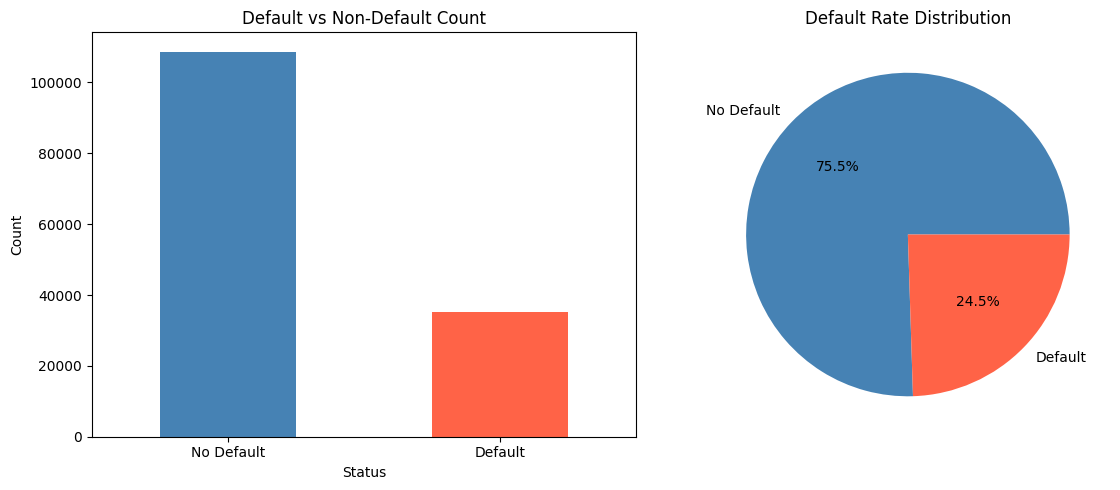

In [15]:
# Overall Default Rate Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
df['Status'].value_counts().plot(kind='bar', ax=axes[0],
    color=['steelblue', 'tomato'])
axes[0].set_title("Default vs Non-Default Count")
axes[0].set_xticklabels(['No Default', 'Default'], rotation=0)
axes[0].set_ylabel("Count")

# Pie chart
df['Status'].value_counts().plot(kind='pie', ax=axes[1],
    labels=['No Default', 'Default'],
    colors=['steelblue', 'tomato'],
    autopct='%1.1f%%')
axes[1].set_title("Default Rate Distribution")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

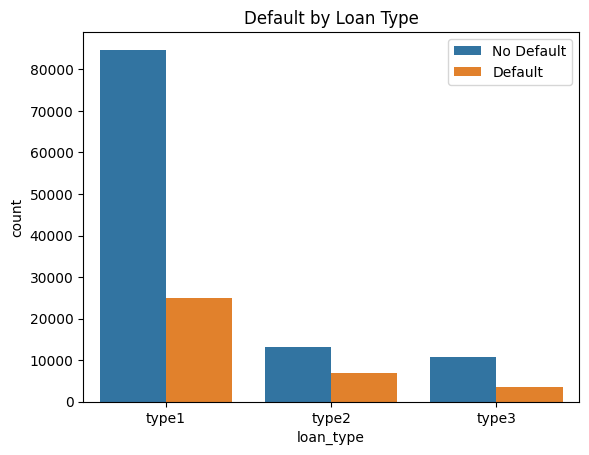

In [16]:
sns.countplot(x='loan_type', hue='Status', data=df)
plt.title("Default by Loan Type")
plt.legend(['No Default', 'Default'])
plt.show()

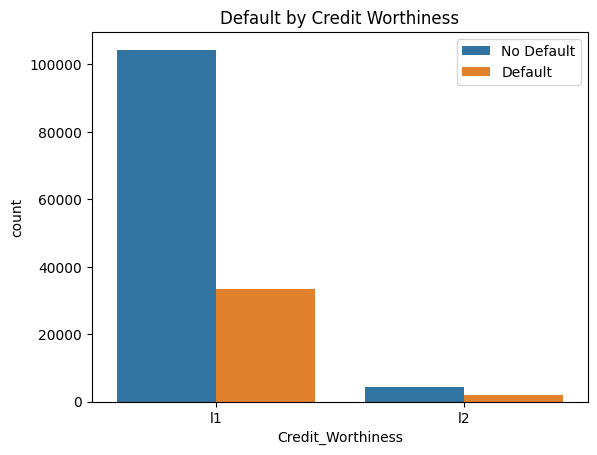

In [17]:
sns.countplot(x='Credit_Worthiness', hue='Status', data=df)
plt.title("Default by Credit Worthiness")
plt.legend(['No Default', 'Default'])
plt.show()

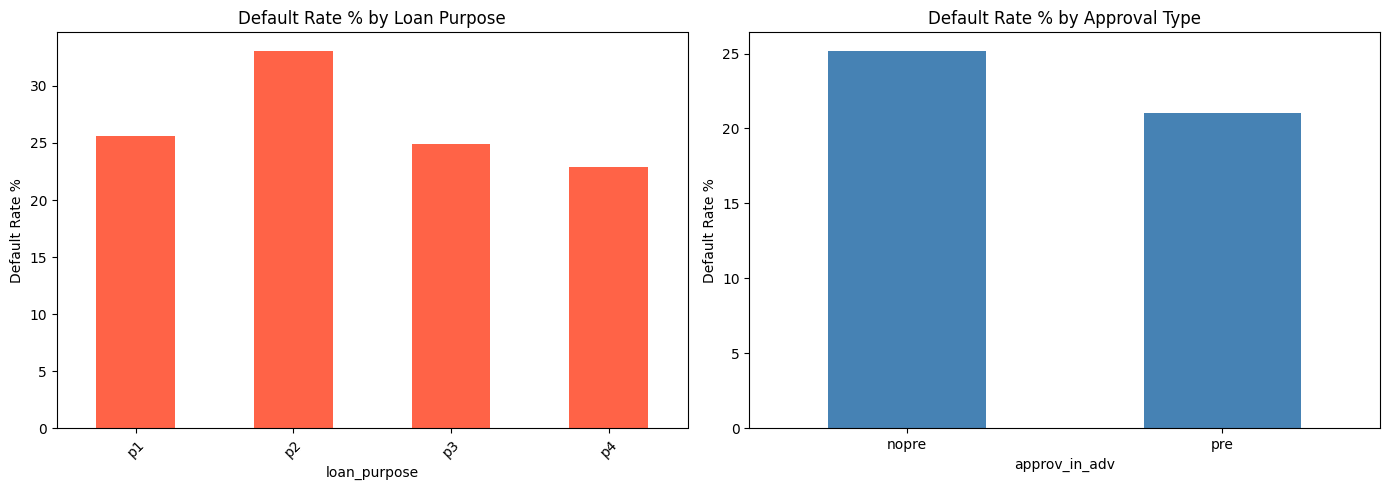

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Default by Loan Purpose
default_by_purpose = df.groupby('loan_purpose')['Status'].mean().mul(100).round(2)
default_by_purpose.plot(kind='bar', ax=axes[0], color='tomato')
axes[0].set_title("Default Rate % by Loan Purpose")
axes[0].set_ylabel("Default Rate %")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

# Default by Approv in Advance
default_by_approv = df.groupby('approv_in_adv')['Status'].mean().mul(100).round(2)
default_by_approv.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title("Default Rate % by Approval Type")
axes[1].set_ylabel("Default Rate %")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

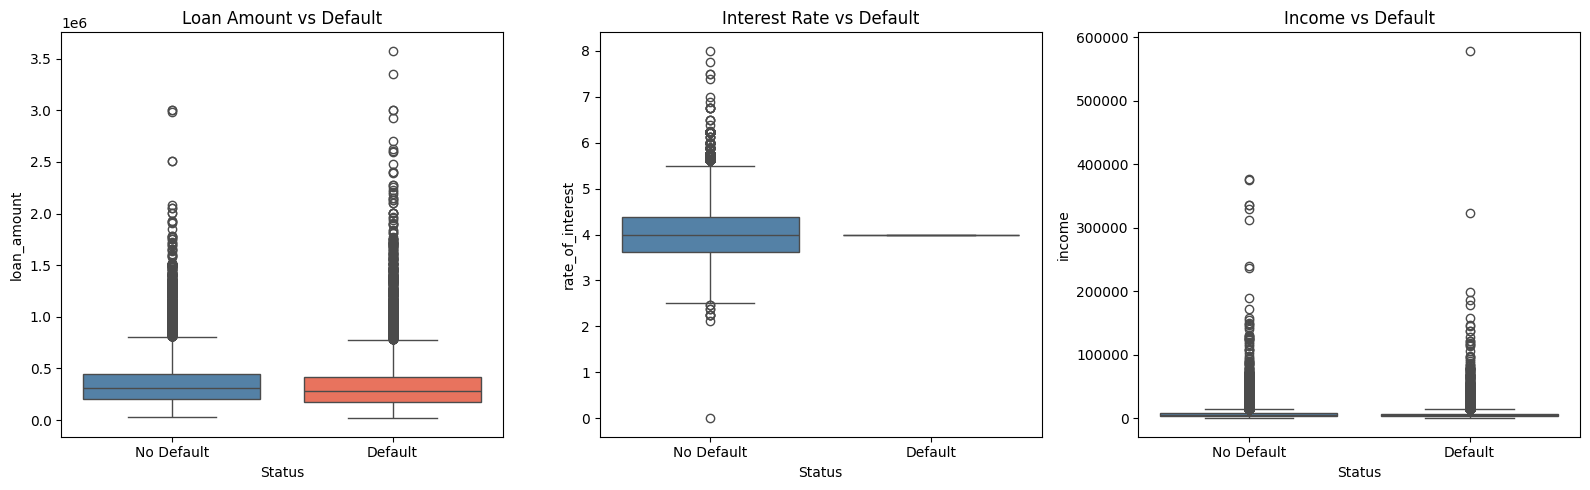

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Loan Amount vs Default
sns.boxplot(x='Status', y='loan_amount', data=df, ax=axes[0],
    palette=['steelblue', 'tomato'])
axes[0].set_title("Loan Amount vs Default")
axes[0].set_xticklabels(['No Default', 'Default'])

# Rate of Interest vs Default
sns.boxplot(x='Status', y='rate_of_interest', data=df, ax=axes[1],
    palette=['steelblue', 'tomato'])
axes[1].set_title("Interest Rate vs Default")
axes[1].set_xticklabels(['No Default', 'Default'])

# Income vs Default
sns.boxplot(x='Status', y='income', data=df, ax=axes[2],
    palette=['steelblue', 'tomato'])
axes[2].set_title("Income vs Default")
axes[2].set_xticklabels(['No Default', 'Default'])

plt.tight_layout()
plt.show()

In [20]:
# Chi-square test for categorical variables
from scipy.stats import chi2_contingency

cols_to_test = ['loan_type', 'Credit_Worthiness', 
                'approv_in_adv', 'loan_purpose']

print("Chi-Square Test Results:")
print("-" * 45)
for col in cols_to_test:
    ct = pd.crosstab(df[col], df['Status'])
    chi2, p, dof, expected = chi2_contingency(ct)
    significance = "✓ Significant" if p < 0.05 else "✗ Not Significant"
    print(f"{col:25} p={p:.4f}  {significance}")

Chi-Square Test Results:
---------------------------------------------
loan_type                 p=0.0000  ✓ Significant
Credit_Worthiness         p=0.0000  ✓ Significant
approv_in_adv             p=0.0000  ✓ Significant
loan_purpose              p=0.0000  ✓ Significant


In [21]:
# High risk loan flag
df['HighRisk'] = ((df['rate_of_interest'] > df['rate_of_interest'].quantile(0.75)) & 
                  (df['loan_amount'] > df['loan_amount'].quantile(0.75))).astype(int)

# Loan amount categories
df['LoanAmountGroup'] = pd.cut(df['loan_amount'],
    bins=[0, 100000, 300000, 500000, float('inf')],
    labels=['Small', 'Medium', 'Large', 'Very Large'])

print("Feature Engineering done!")
print(df[['HighRisk', 'LoanAmountGroup']].value_counts())

# Save enriched file
df.to_csv("loan_enriched.csv", index=False)
print("Saved!")

Feature Engineering done!
HighRisk  LoanAmountGroup
0         Medium             66092
          Large              46728
          Very Large         17785
          Small               6526
1         Very Large          4597
          Large               2255
          Medium                 0
          Small                  0
Name: count, dtype: int64
Saved!


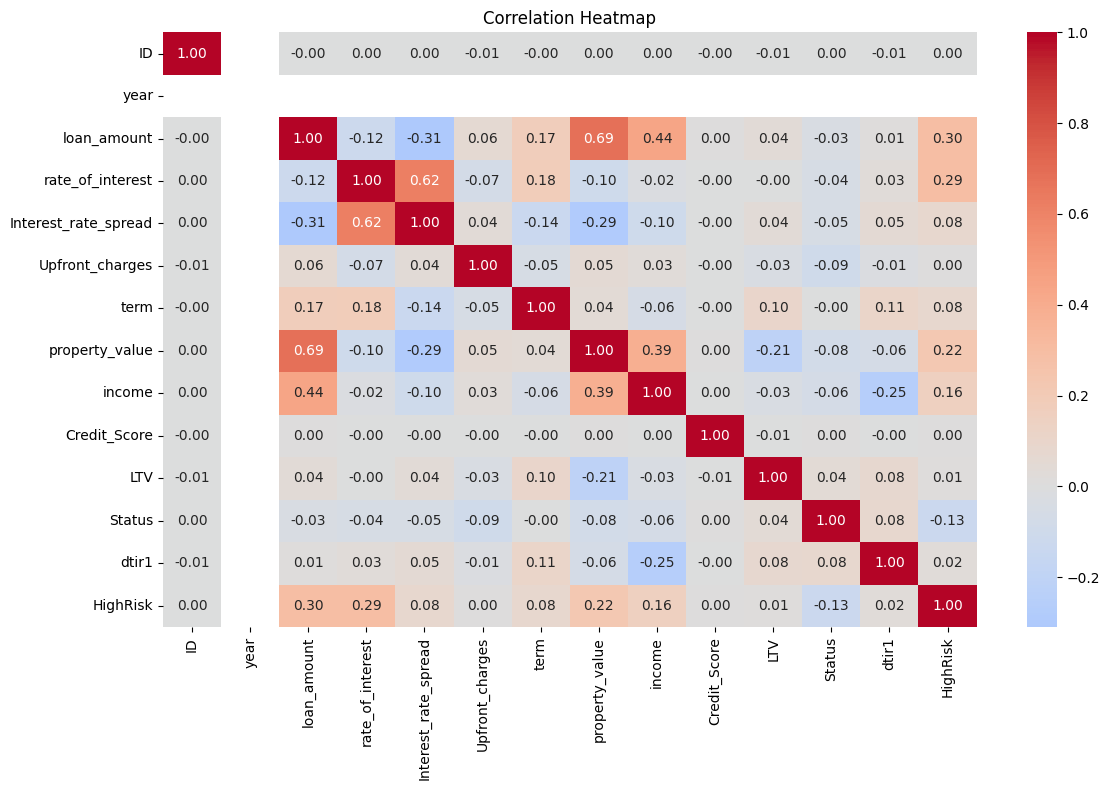

In [22]:
# Select numeric columns only
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## Key Findings from EDA

1. **Default Rate: 24.5%** — 1 in 4 loans defaults
2. **Loan Type**: Type1 has highest default volume
3. **Credit Worthiness**: l1 customers default most
4. **Loan Purpose**: p2 has highest default rate (33%)
5. **Pre-approval**: Non pre-approved loans default more
6. **Interest Rate**: Defaulted loans have higher rates
7. **Income**: Not a strong standalone predictor

## Business Recommendations
- Stricter checks for Type1 loans
- Mandatory pre-approval process
- Cap interest rates for high-risk borrowers
- Focus on Credit Worthiness l1 segment

In [24]:
df.to_csv("loan_enriched.csv", index=False)
print("Final shape:", df.shape)
print("Columns:", df.columns.tolist())
print("File saved ")

Final shape: (143983, 36)
Columns: ['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'property_value', 'construction_type', 'occupancy_type', 'Secured_by', 'total_units', 'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type', 'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type', 'Status', 'dtir1', 'HighRisk', 'LoanAmountGroup']
File saved 
